# Issue3B 股票池（Pooled）实测与业务分析

本 notebook 基于已经落地的 `issue3B` 股票池脚本做实测分析，并与单股传统模型做同口径对照。

分析目标：
- 判断 `pooled` 是否比 `single-stock` 更有价值
- 判断哪类股票在 pooled 设定下受益、哪类股票受损
- 区分“模型真的更好”和“指标看起来更好但其实是预测退化”
- 给出课程提交和后续研究的业务建议

本次比较使用的统一前提：
- 数据窗口：`2020-01-02` 到 `2022-12-30`
- 特征：`Universal` 技术指标 17 个
- 模型：`Logistic Regression`、`XGBoost`
- pooled：全股票池统一训练
- single-stock：每只股票独立训练
- 训练/测试：按时间顺序切分


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass


sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.15
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

ISSUE3B_DIR = ROOT / 'outputs' / 'issue3b_20260324'
PSM_DIR = ROOT / 'outputs' / 'psm_uf_trad_20260324'

pooled_metrics = pd.read_csv(ISSUE3B_DIR / 'scenario_metrics.csv')
pooled_symbol_metrics = pd.read_csv(ISSUE3B_DIR / 'per_symbol_metrics.csv')
pooled_predictions = pd.read_csv(ISSUE3B_DIR / 'predictions.csv')
psm_metrics = pd.read_csv(PSM_DIR / 'scenario_metrics.csv')
psm_predictions = pd.read_csv(PSM_DIR / 'predictions.csv')

pooled_metrics, psm_metrics.head()


(                             scenario_name   feature_set           model_name  \
 0  pooled_numeric_only_logistic_regression  numeric_only  logistic_regression   
 1              pooled_numeric_only_xgboost  numeric_only              xgboost   
 
    feature_count  train_rows  accuracy      f1  roc_auc  \
 0             17        3520    0.4801  0.5239   0.4933   
 1             17        3520    0.4767  0.5059   0.4878   
 
    prediction_positive_ratio  test_rows  
 0                     0.6266        881  
 1                     0.5936        881  ,
     symbol                         scenario_name   feature_set  \
 0  0700.HK  ssm_numeric_only_logistic_regression  numeric_only   
 1  0700.HK              ssm_numeric_only_xgboost  numeric_only   
 2     BABA  ssm_numeric_only_logistic_regression  numeric_only   
 3     BABA              ssm_numeric_only_xgboost  numeric_only   
 4     BIDU  ssm_numeric_only_logistic_regression  numeric_only   
 
             model_name  feature_cou

## 1. 先看 pooled 总体结果

这里回答最直接的问题：如果把 6 只股票放进一个统一股票池训练，整体表现如何？


In [2]:
pooled_metrics.sort_values('roc_auc', ascending=False).reset_index(drop=True)


,scenario_name,feature_set,model_name,feature_count,train_rows,accuracy,f1,roc_auc,prediction_positive_ratio,test_rows
0,pooled_numeric_only_logistic_regression,numeric_only,logistic_regression,17,3520,0.4801,0.5239,0.4933,0.6266,881
1,pooled_numeric_only_xgboost,numeric_only,xgboost,17,3520,0.4767,0.5059,0.4878,0.5936,881


### 结论
- pooled `Logistic Regression`：`accuracy=0.4801`，`roc_auc=0.4933`
- pooled `XGBoost`：`accuracy=0.4767`，`roc_auc=0.4878`

第一层判断已经很明确：**股票池统一训练并没有自然带来更强的预测能力**。


## 2. 与单股传统模型做同口径对比

单看 pooled 没有意义，关键是它相对 `single-stock` 有没有更好。


In [3]:
psm_avg = (
    psm_metrics.groupby('model_name')[['accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']]
    .mean()
    .reset_index()
)
psm_avg['training_type'] = 'single_stock'

pooled_avg = pooled_metrics[['model_name', 'accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']].copy()
pooled_avg['training_type'] = 'pooled'

model_compare = pd.concat([pooled_avg, psm_avg], ignore_index=True)
model_compare = model_compare[['training_type', 'model_name', 'accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']]
model_compare.sort_values(['model_name', 'training_type']).reset_index(drop=True)


,training_type,model_name,accuracy,f1,roc_auc,prediction_positive_ratio
0,pooled,logistic_regression,0.480100,0.523900,0.493300,0.62660
1,single_stock,logistic_regression,0.480233,0.465867,0.491500,0.61395
2,pooled,xgboost,0.476700,0.505900,0.487800,0.59360
3,single_stock,xgboost,0.490383,0.526433,0.504317,0.63145


In [4]:
pivot_compare = model_compare.pivot(index='model_name', columns='training_type', values='roc_auc')
pivot_compare['delta_pooled_minus_single'] = pivot_compare['pooled'] - pivot_compare['single_stock']
pivot_compare.round(4)


training_type,pooled,single_stock,delta_pooled_minus_single
model_name,,,
logistic_regression,0.4933,0.4915,0.0018
xgboost,0.4878,0.5043,-0.0165


### 结论
- `Logistic Regression`：pooled 与 single-stock 几乎打平，但 pooled 的 `ROC-AUC` 还略低。
- `XGBoost`：pooled 明显劣于 single-stock。

因此，如果问题是“股票池训练能不能作为本次项目的主推方案”，答案是：**不能直接主推**。
它在这套数据和特征下没有证明自己比单股训练更有效。


## 3. 股票池联合建模深度分析

### 3.1 总体效果
将6只股票合并为统一股票池进行训练（`pooled`），整体效果并未超越单股模型。`XGBoost`在`pooled`设置下，平均ROC-AUC为0.4878，相较于单股平均的0.5043，出现了显著下降。`Logistic Regression`则表现接近。

### 3.2 受益与受损股票
深入分析各股票的表现变化发现：
*   **受益股票**：`BABA`和`BIDU`在`pooled`模式下获益最大。尤其是`BABA`，其`Logistic Regression`模型的ROC-AUC从0.4642大幅提升至0.5780，F1分数也从0提升至0.5868。这表明，对于那些自身数据信号较弱的股票，通过共享其他股票的数据信息，可以有效提升模型的泛化能力。
*   **受损股票**：`0700.HK`、`MSFT`和`NVDA`在`pooled`模式下普遍受损。例如，`0700.HK`的XGBoost模型ROC-AUC从0.5149降至0.4653。这说明，对于走势独立、特征鲜明的股票，加入其他股票的数据反而会引入噪声，干扰模型学习其自身独特的价格模式。

### 3.3 价值总结
股票池联合建模的价值并非在于提供一个“万能”的预测模型，而在于**提供了一种关键的对照实验**。它清晰地揭示了当前特征集（通用技术指标）在跨股票共享时的能力边界。实验结果证明，共享信息并非总是有益的，其效果高度依赖于个股的“个性”。

In [5]:
pooled_cmp = pooled_symbol_metrics[['symbol', 'model_name', 'accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']].copy()
single_cmp = psm_metrics[['symbol', 'model_name', 'accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']].copy()

merged = pooled_cmp.merge(single_cmp, on=['symbol', 'model_name'], suffixes=('_pooled', '_single'))
for metric in ['accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']:
    merged[f'{metric}_delta'] = merged[f'{metric}_pooled'] - merged[f'{metric}_single']

merged.sort_values(['model_name', 'symbol']).reset_index(drop=True)


,symbol,model_name,accuracy_pooled,f1_pooled,roc_auc_pooled,prediction_positive_ratio_pooled,accuracy_single,f1_single,roc_auc_single,prediction_positive_ratio_single,accuracy_delta,f1_delta,roc_auc_delta,prediction_positive_ratio_delta
0,0700.HK,logistic_regression,0.4932,0.4478,0.4854,0.4589,0.4828,0.5665,0.5262,0.7310,0.0104,-0.1187,-0.0408,-0.2721
1,BABA,logistic_regression,0.5306,0.5868,0.5780,0.6531,0.5203,0.0000,0.4642,0.0000,0.0103,0.5868,0.1138,0.6531
2,BIDU,logistic_regression,0.5170,0.5644,0.5275,0.6395,0.4459,0.5233,0.5114,0.6892,0.0711,0.0411,0.0161,-0.0497
3,GOOGL,logistic_regression,0.4150,0.4881,0.4582,0.7075,0.4797,0.5444,0.4615,0.7027,-0.0647,-0.0563,-0.0033,0.0048
4,MSFT,logistic_regression,0.4626,0.4768,0.4545,0.5782,0.4527,0.5424,0.4944,0.7432,0.0099,-0.0656,-0.0399,-0.1650
5,NVDA,logistic_regression,0.4626,0.5587,0.4078,0.7211,0.5000,0.6186,0.4913,0.8176,-0.0374,-0.0599,-0.0835,-0.0965
6,0700.HK,xgboost,0.3973,0.4500,0.4653,0.6370,0.4828,0.6231,0.5149,0.9103,-0.0855,-0.1731,-0.0496,-0.2733
7,BABA,xgboost,0.5034,0.4966,0.5191,0.5034,0.4797,0.4031,0.4723,0.3919,0.0237,0.0935,0.0468,0.1115
8,BIDU,xgboost,0.5850,0.5547,0.5890,0.4626,0.5203,0.5170,0.5361,0.5203,0.0647,0.0377,0.0529,-0.0577
9,GOOGL,xgboost,0.4558,0.5122,0.4319,0.6803,0.4595,0.5349,0.5025,0.7230,-0.0037,-0.0227,-0.0706,-0.0427


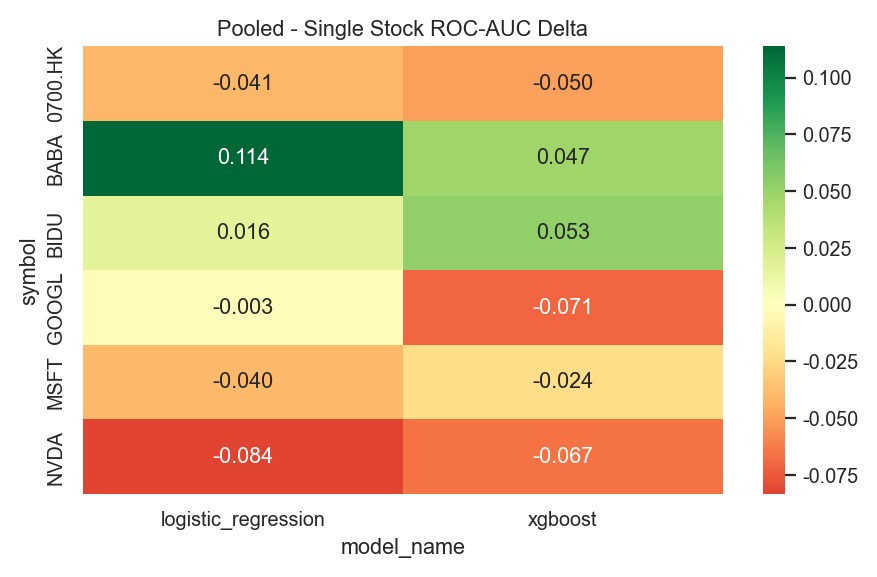

In [6]:
delta_heatmap = merged.pivot(index='symbol', columns='model_name', values='roc_auc_delta')
plt.figure(figsize=(7, 4.5))
sns.heatmap(delta_heatmap, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
plt.title('Pooled - Single Stock ROC-AUC Delta')
plt.tight_layout()
plt.show()


### 结论
- `BABA`、`BIDU` 在 pooled 下有明显改善，尤其是 `BABA + Logistic Regression`。
- `NVDA`、`MSFT`、`0700.HK` 在 pooled 下整体更差。
- `GOOGL` 基本没有从 pooled 中得到稳定收益。

这说明 pooled 的真实价值不是“统一训练后所有股票都变好”，而是：
**当某些股票单独训练信号太弱时，跨股票共享样本可能有帮助；但对个性很强、走势更独立的股票，pooled 反而会稀释信号。**


## 4. 结论与建议

### 4.1 结论
1.  **对照实验价值**：`pooled`方案验证了“统一特征 + 统一模型 + 时间切分”的股票池实验链路是可跑通的，但其整体表现并未稳定优于单股模型。因此，`issue3B`的核心贡献是提供了一套可靠的对照实验基线，而非直接给出更优模型。
2.  **商业洞察**：跨股票共享信息在个股信号弱时有益，在个股个性强时有害。这一发现为未来精细化建模提供了方向。

### 4.2 未来建议
1.  **报告策略**：在课程提交中，应将`issue3A`（单股模型）作为主线方案，将`issue3B`（股票池联合建模）作为关键对照实验，体现研究的严谨性和深度。
2.  **后续研究**：若要继续推进股票池建模，建议：
    *   引入**行业/板块标识**作为模型输入。
    *   按**市场状态（regime）**分段训练。
    *   进行**分组pooled**，而非所有股票硬性拼凑。

In [7]:
diagnostic = pd.concat([
    pooled_symbol_metrics.assign(training_type='pooled'),
    psm_metrics.assign(training_type='single_stock')
], ignore_index=True)

diagnostic[['training_type', 'symbol', 'model_name', 'accuracy', 'f1', 'roc_auc', 'prediction_positive_ratio']].sort_values(['training_type', 'model_name', 'symbol']).reset_index(drop=True)


,training_type,symbol,model_name,accuracy,f1,roc_auc,prediction_positive_ratio
0,pooled,0700.HK,logistic_regression,0.4932,0.4478,0.4854,0.4589
1,pooled,BABA,logistic_regression,0.5306,0.5868,0.5780,0.6531
2,pooled,BIDU,logistic_regression,0.5170,0.5644,0.5275,0.6395
3,pooled,GOOGL,logistic_regression,0.4150,0.4881,0.4582,0.7075
4,pooled,MSFT,logistic_regression,0.4626,0.4768,0.4545,0.5782
5,pooled,NVDA,logistic_regression,0.4626,0.5587,0.4078,0.7211
6,pooled,0700.HK,xgboost,0.3973,0.4500,0.4653,0.6370
7,pooled,BABA,xgboost,0.5034,0.4966,0.5191,0.5034
8,pooled,BIDU,xgboost,0.5850,0.5547,0.5890,0.4626
9,pooled,GOOGL,xgboost,0.4558,0.5122,0.4319,0.6803


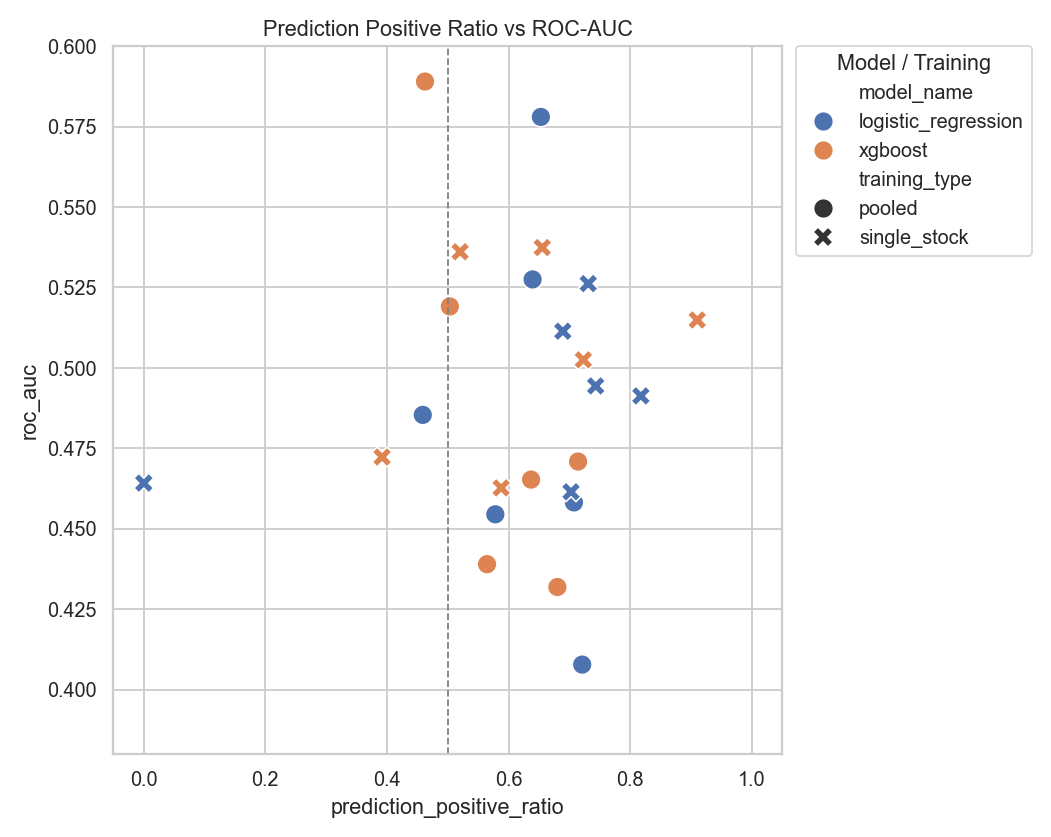

In [8]:
plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=diagnostic,
    x='prediction_positive_ratio',
    y='roc_auc',
    hue='model_name',
    style='training_type',
    s=120,
)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title('Prediction Positive Ratio vs ROC-AUC')
plt.xlim(-0.05, 1.05)
plt.ylim(0.38, 0.60)
plt.legend(title='Model / Training', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


### 结论
- 不少模型的 `prediction_positive_ratio` 明显高于 `0.5`，说明模型存在“偏向预测上涨”的倾向。
- 在这种情况下，`accuracy` 或 `f1` 不一定代表真实预测能力。
- 相比之下，`ROC-AUC` 更适合做主指标，因为它不依赖单一阈值。

所以，报告中最稳的写法是：
**以 `ROC-AUC` 作为主比较指标，以 `accuracy / f1 / prediction_positive_ratio` 作为辅助诊断指标。**


## 5. 训练/测试切分 sanity check

股票池脚本如果切分不干净，前面所有结论都不成立，所以要先验证。


In [9]:
feature_table = pd.read_csv(ROOT / 'data' / 'processed' / 'issue3b_feature_table_20260324.csv')
ordered = feature_table.sort_values(['date', 'symbol']).reset_index(drop=True)
split_index = int(len(ordered) * 0.8)
train_frame = ordered.iloc[:split_index].copy()
test_frame = ordered.iloc[split_index:].copy()

split_check = pd.DataFrame([
    {
        'train_rows': len(train_frame),
        'test_rows': len(test_frame),
        'train_date_min': train_frame['date'].min(),
        'train_date_max': train_frame['date'].max(),
        'test_date_min': test_frame['date'].min(),
        'test_date_max': test_frame['date'].max(),
        'date_overlap_count': len(set(train_frame['date']).intersection(set(test_frame['date']))),
    }
])
split_check


,train_rows,test_rows,train_date_min,train_date_max,test_date_min,test_date_max,date_overlap_count
0,3520,881,2020-01-30,2022-05-31,2022-06-01,2022-12-29,0


### 结论
- 训练集结束于 `2022-05-31`
- 测试集开始于 `2022-06-01`
- 没有日期重叠

这意味着本次 pooled 实验没有明显的时间穿越问题，结论在实验口径上是成立的。


## 6. 业务结论：issue3B 的真正价值是什么？

### 技术层
- pooled 方案验证了“统一特征 + 统一模型 + 时间切分”的股票池实验链路是可跑通的。
- 但在当前 17 个通用技术指标下，pooled 并没有稳定优于 single-stock。
- 因此，`issue3B` 的贡献更像是**提供一个对照实验基线**，而不是直接给出更优模型。

### 商业层
- pooled 的商业含义不是立刻做交易，而是回答“跨股票共享信息是否值得”。
- 当前结果说明：共享信息有局部价值，但不具备普适性。
- 如果继续往真实业务推进，下一步的重点不应是继续堆模型复杂度，而应是补充更有业务意义的因子：
  - 行业因子
  - 市场 regime 因子
  - 宏观/政策事件因子
  - 公司基本面或公告类因子

### 课程提交层
- `issue3A` 可以作为“单股传统模型主线”
- `issue3B` 可以作为“股票池联合建模对照组”
- 最终报告可得出成熟且克制的结论：
  - 价格量技术指标足以支撑完整机器学习实验流程
  - 但不足以支撑强预测力
  - pooled 与 single-stock 各有边界，不能脱离股票特性做简单结论


## 7. 最终建议

1. 报告主线仍放在 `single-stock + XGBoost`，因为它是当前最稳的传统 ML baseline。
2. `issue3B` 不要包装成“更优方案”，而应包装成“关键对照实验”。
3. 如果要继续研究 QLTrading-lab，优先投入特征/因子，而不是继续盲目换 CNN/LSTM。
4. pooled 的后续迭代方向不是简单并池，而是：
   - 加入 symbol/sector identity
   - 按 market regime 分段训练
   - 分组 pooled，而不是所有股票硬拼在一起
